In [123]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

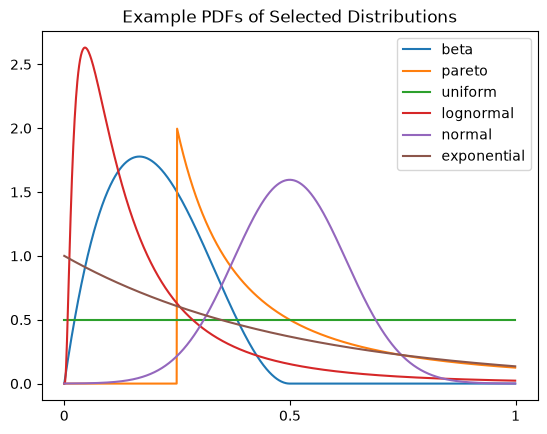

In [167]:
X = np.linspace(0, 2, 1000)

plt.plot(stats.beta.pdf(X, a=2, b=3), label='beta')
plt.plot(stats.pareto.pdf(X, b=1, scale=0.5), label='pareto')
plt.plot(stats.uniform.pdf(X, loc=0, scale=2), label='uniform')
plt.plot(stats.lognorm.pdf(X, s=1, scale=0.25), label='lognormal')
plt.plot(stats.norm.pdf(X, loc=1, scale=0.25), label='normal')
plt.plot(stats.expon.pdf(X, scale=1), label='exponential')

plt.xticks([0, 500, 1000], [0, 0.5, 1])

plt.title('Example PDFs of Selected Distributions')
plt.legend()
plt.show()

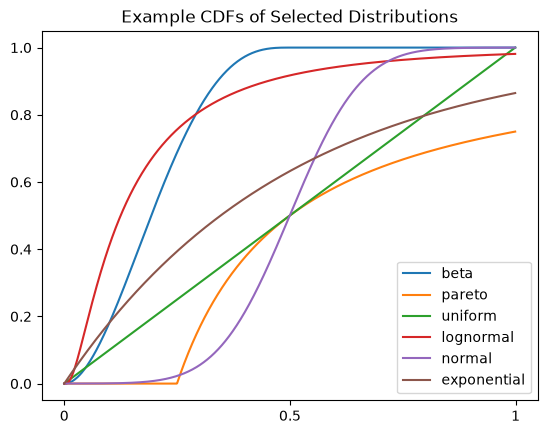

In [168]:
plt.plot(stats.beta.cdf(X, a=2, b=3), label='beta')
plt.plot(stats.pareto.cdf(X, b=1, scale=0.5), label='pareto')
plt.plot(stats.uniform.cdf(X, loc=0, scale=2), label='uniform')
plt.plot(stats.lognorm.cdf(X, s=1, scale=0.25), label='lognormal')
plt.plot(stats.norm.cdf(X, loc=1, scale=0.25), label='normal')
plt.plot(stats.expon.cdf(X, scale=1), label='exponential')

plt.xticks([0, 500, 1000], [0, 0.5, 1])

plt.title('Example CDFs of Selected Distributions')
plt.legend()
plt.show()

# Q1

In [126]:
def random_draw(K, n):
    X = np.linspace(1/K, 1, K)
    Y = np.random.choice(X, size=n)

    sns.ecdfplot(Y)
    plt.title(f'K = {K}, n = {n}')
    plt.show()

    return Y

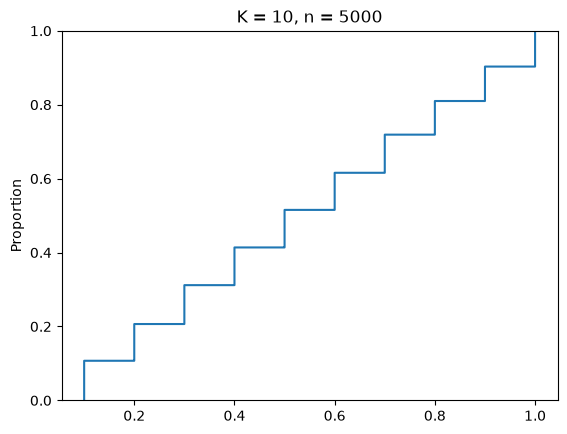

array([0.3, 0.8, 0.9, ..., 0.4, 0.7, 0.5], shape=(5000,))

In [127]:
random_draw(K=10, n=5000)

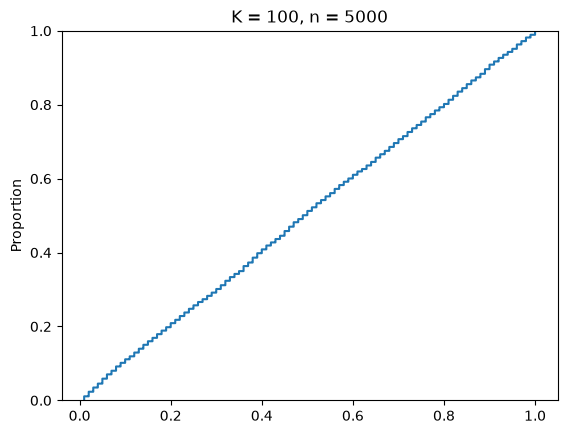

array([0.51, 0.86, 0.31, ..., 0.05, 0.68, 0.7 ], shape=(5000,))

In [128]:
random_draw(K=100, n=5000)

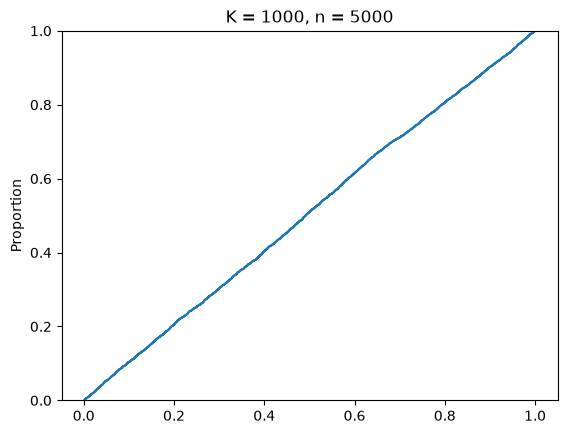

array([0.77 , 0.666, 0.169, ..., 0.254, 0.635, 0.972], shape=(5000,))

In [129]:
random_draw(K=1000, n=5000)

The ECDF appears like a step function with low K. As K increases, it approaches a straight line with slope 1, which is the CDF of the Uniform distribution from 0 to 1.

# Q2

In [130]:
def sample_mean(b, n=32):
    means = []
    for i in range(b):
        sample = np.random.random(size=n)
        sample = np.sqrt(3) * (2*sample - 1)

        means.append(sample.mean() * np.sqrt(n))

    means = np.array(means)
    
    sns.ecdfplot(means)
    plt.title(f'b = {b}, n = {n}')
    plt.show()
    
    # return means

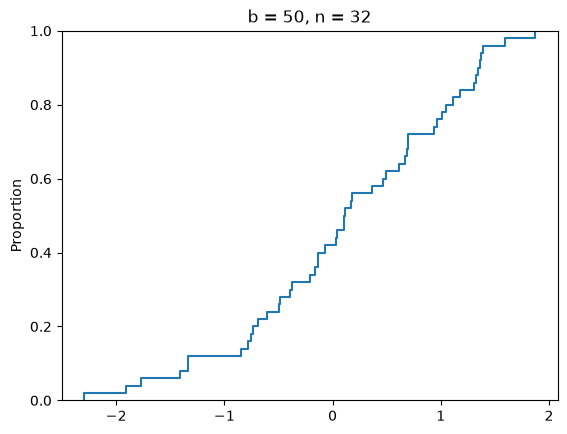

In [131]:
sample_mean(50)

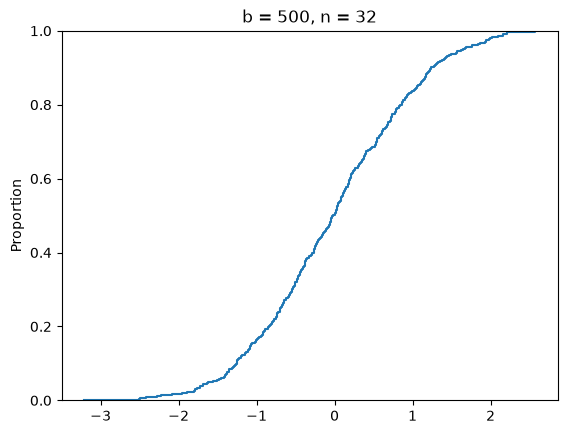

In [132]:
sample_mean(500)

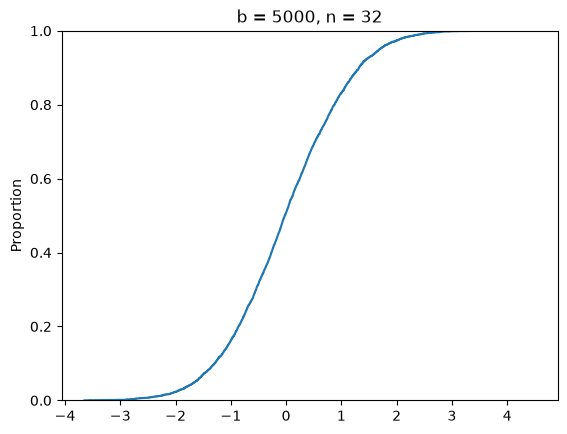

In [133]:
sample_mean(5000)

This looks like the CDF of a normal distribution. As n increases, it will approach an exact normal CDF.

# Q5

In [134]:
def rank_values(rank, n, K=20):
    vals = []
    for i in range(n):
        sample = np.random.random(size=K)
        sample.sort(descending=True)

        vals.append(sample[rank-1])

    # sns.ecdfplot(vals)
    # plt.title(f'rank = {rank}, n = {n}')
    # plt.show()

    return vals

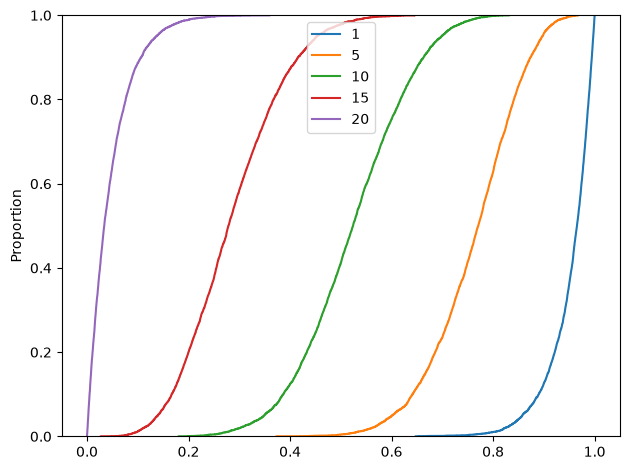

In [139]:
for rank in [1, 5, 10, 15, 20]:
    sns.ecdfplot(rank_values(rank, 5000), label=rank)
plt.legend()
plt.tight_layout()
plt.show()

These distributions match the CDF's of beta distributions.

The expectation of the distribution increases as rank gets better (assuming rank 1 as the best).

# Q8

In [159]:
# I used b=10,000 instead of 1,000,000 since it was too slow
# It still gives a good estimate of the distribution

def particle_model(energy=1, n=1000, b=10000):
    E = energy * np.ones(n)
    
    for step in range(b):
        i, j = np.random.choice(range(n), size=2, replace=False)

        E_sum = E[i] + E[j]
        u = np.random.random()

        E[i] = u*E_sum
        E[j] = (1-u)*E_sum

    sns.ecdfplot(E)
    plt.title(f'E = {energy}, n = {n}')
    plt.show()

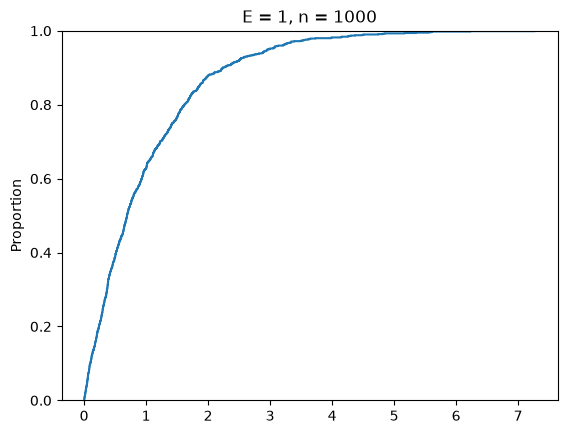

In [160]:
particle_model()

As n becomes large, this approaches the CDF of an exponential distribution.

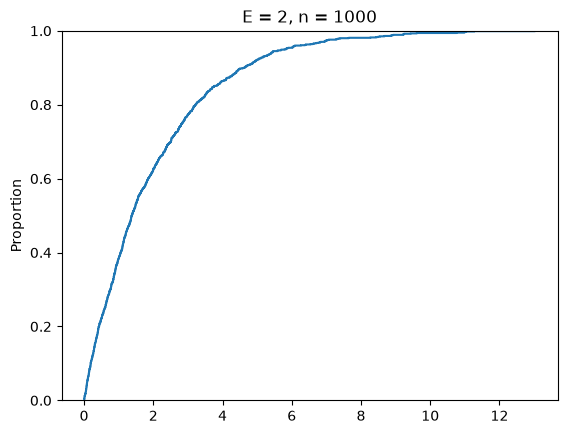

In [175]:
particle_model(energy=2)

When starting energy changes, the distribution shape stays the same, it is just scaled by the energy.